In [138]:
pip install pandas

You should consider upgrading via the '/usr/local/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [139]:
pip install pingouin

You should consider upgrading via the '/usr/local/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [140]:
import pandas as pd
import pingouin as pg
import numpy as np
import matplotlib.pyplot as plt
import re
import statsmodels.formula.api as smf


df = pd.read_csv("chatbot_debate_user_study_V2.csv")

In [141]:
# Reliability Engagement A with Cronbach's Alpha
pg.cronbach_alpha(df[['eng1_A', 'eng2_A', 'eng3_A']])


(np.float64(0.7476875642343267), array([0.458, 0.895]))

In [142]:
# Reliability Engagement A with Inter-Item
pg.cronbach_alpha(df[['eng1_A', 'eng2_A', 'eng3_A']])
df[['eng1_A', 'eng2_A', 'eng3_A']].corr()

,eng1_A,eng2_A,eng3_A
eng1_A,1.000000,0.262116,0.646589
eng2_A,0.262116,1.000000,0.575849
eng3_A,0.646589,0.575849,1.000000


In [143]:
# Reliability Engagement B with Cronbach's Alpha
pg.cronbach_alpha(df[['eng1_B', 'eng2_B', 'eng3_B']])


(np.float64(0.6558139534883721), array([0.261, 0.857]))

In [144]:
# Reliability Engagement B with Inter-Item
pg.cronbach_alpha(df[['eng1_B', 'eng2_B', 'eng3_B']])
df[['eng1_B', 'eng2_B', 'eng3_B']].corr()

,eng1_B,eng2_B,eng3_B
eng1_B,1.000000,0.244052,0.464935
eng2_B,0.244052,1.000000,0.447499
eng3_B,0.464935,0.447499,1.000000


In [145]:
# Reliability Engagement C with Inter-Item
pg.cronbach_alpha(df[['eng1_C', 'eng2_C', 'eng3_C']])
df[['eng1_C', 'eng2_C', 'eng3_C']].corr()


,eng1_C,eng2_C,eng3_C
eng1_C,1.000000,0.057079,0.483786
eng2_C,0.057079,1.000000,0.409153
eng3_C,0.483786,0.409153,1.000000


In [146]:
# Reliability Engagement C with Cronbach's Alpha
pg.cronbach_alpha(df[['eng1_C', 'eng2_C', 'eng3_C']])

(np.float64(0.5909547738693467), array([0.121, 0.83 ]))

In [147]:
# Reliability trust A with Cronbach's Alpha
pg.cronbach_alpha(df[['trust1_A', 'trust2_A']])

(np.float64(0.7696969696969695), array([0.402, 0.911]))

In [148]:
# Reliability Trust A with Inter-Item Korrelation
pg.cronbach_alpha(df[['trust1_A', 'trust2_A']])
df[['trust1_A', 'trust2_A']].corr()

,trust1_A,trust2_A
trust1_A,1.000000,0.651839
trust2_A,0.651839,1.000000


In [149]:
# Reliability trust B with Cronbach's Alpha
pg.cronbach_alpha(df[['trust1_B', 'trust2_B']])

(np.float64(0.8240963855421688), array([0.543, 0.932]))

In [150]:
# Reliability Trust B with Inter-Item Korrelation
pg.cronbach_alpha(df[['trust1_B', 'trust2_B']])
df[['trust1_B', 'trust2_B']].corr()

,trust1_B,trust2_B
trust1_B,1.00000,0.72302
trust2_B,0.72302,1.00000


In [151]:
# Reliability trust C with Cronbach's Alpha
pg.cronbach_alpha(df[['trust1_C', 'trust2_C']])

(np.float64(0.9472140762463341), array([0.863, 0.98 ]))

In [152]:
# Reliability Trust C with Inter-Item Korrelation
pg.cronbach_alpha(df[['trust1_C', 'trust2_C']])
df[['trust1_C', 'trust2_C']].corr()

,trust1_C,trust2_C
trust1_C,1.000000,0.912124
trust2_C,0.912124,1.000000


In [153]:
# Reliability open A with Cronbach's Alpha
pg.cronbach_alpha(df[['open1_A', 'open2_A']])

(np.float64(0.6178861788617884), array([0.008, 0.853]))

In [154]:
# Reliability Openness A with Inter-Item Korrelation
pg.cronbach_alpha(df[['open1_A', 'open2_A']])
df[['open1_A', 'open2_A']].corr()

,open1_A,open2_A
open1_A,1.000000,0.473486
open2_A,0.473486,1.000000


In [155]:
# Reliability open B with Cronbach's Alpha
pg.cronbach_alpha(df[['open1_B', 'open2_B']])

(np.float64(0.4444444444444444), array([-0.442,  0.786]))

In [156]:
# Reliability Openness B with Inter-Item Korrelation
pg.cronbach_alpha(df[['open1_B', 'open2_B']])
df[['open1_B', 'open2_B']].corr()

,open1_B,open2_B
open1_B,1.000000,0.285947
open2_B,0.285947,1.000000


In [157]:
# Reliability open C with Cronbach's Alpha
pg.cronbach_alpha(df[['open1_C', 'open2_C']])

(np.float64(0.8428835489833642), array([0.592, 0.939]))

In [158]:
# Reliability Openness C with Inter-Item Korrelation
pg.cronbach_alpha(df[['open1_C', 'open2_C']])
df[['open1_C', 'open2_C']].corr()

,open1_C,open2_C
open1_C,1.000000,0.731581
open2_C,0.731581,1.000000


In [159]:
# put items into scales
scales = {
    "trust": ["trust1", "trust2"],
    "open": ["open1", "open2"],
    "eng": ["eng1", "eng2", "eng3"]
}

#prototypes
conditions = ["A", "B", "C"]

results = []

#Cronbach's Alpha per Scale and Prototype
for scale, items in scales.items():
    for cond in conditions:
        cols = [f"{item}_{cond}" for item in items]
        alpha, ci = pg.cronbach_alpha(df[cols])
        
        results.append({
            "Scale": scale,
            "Condition": cond,
            "Items": ", ".join(cols),
            "Cronbach_Alpha": round(alpha, 3)
        })

# make table
alpha_table = pd.DataFrame(results)
alpha_table_pivot = alpha_table.pivot(index="Scale", columns="Condition", values="Cronbach_Alpha")

print(alpha_table_pivot)

Condition      A      B      C
Scale                         
eng        0.748  0.656  0.591
open       0.618  0.444  0.843
trust      0.770  0.824  0.947


In [160]:
# same for Inter-Item Correlation per Scale
scales = {
    "trust": ["trust1", "trust2"],
    "open": ["open1", "open2"],
    "eng": ["eng1", "eng2", "eng3"]
}

conditions = ["A", "B", "C"]

results = []

for scale, items in scales.items():
    for cond in conditions:
        cols = [f"{item}_{cond}" for item in items]
        
        corr_matrix = df[cols].corr()
        
        # obere Dreiecksmatrix ohne Diagonale -> alle Itempaare
        mean_corr = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        ).stack().mean()
        
        results.append({
            "Scale": scale,
            "Condition": cond,
            "Mean_Inter_Item_Corr": round(mean_corr, 3)
        })

iter_table = pd.DataFrame(results)

pivot_table = iter_table.pivot(index="Scale", columns="Condition", values="Mean_Inter_Item_Corr")

print(pivot_table)

Condition      A      B      C
Scale                         
eng        0.495  0.385  0.317
open       0.473  0.286  0.732
trust      0.652  0.723  0.912


In [161]:
# Mean Trust
df['trust_A'] = df[['trust1_A', 'trust2_A']].mean(axis=1)
df['trust_B'] = df[['trust1_B', 'trust2_B']].mean(axis=1)
df['trust_C'] = df[['trust1_C', 'trust2_C']].mean(axis=1)

In [162]:
# Mean Open 
df['open_A'] = df[['open1_A', 'open2_A']].mean(axis=1)
df['open_B'] = df[['open1_B', 'open2_B']].mean(axis=1)
df['open_C'] = df[['open1_C', 'open2_C']].mean(axis=1)

In [163]:
# Mean Eng
df['eng_A'] = df[['eng1_A', 'eng2_A', 'eng3_A']].mean(axis=1)
df['eng_B'] = df[['eng1_B', 'eng2_B', 'eng3_B']].mean(axis=1)
df['eng_C'] = df[['eng1_C', 'eng2_C', 'eng3_C']].mean(axis=1)

In [164]:
df.to_csv('daten.csv', index=False)

In [165]:
# show values
df[['trust_A', 'trust_B', 'trust_C',
    'open_A', 'open_B', 'open_C',
    'eng_A', 'eng_B', 'eng_C']].describe()

,trust_A,trust_B,trust_C,open_A,open_B,open_C,eng_A,eng_B,eng_C
count,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000
mean,4.263158,4.131579,4.052632,4.052632,4.026316,4.026316,3.543860,3.719298,3.824561
std,0.694591,0.778926,0.998537,0.848115,0.716350,0.889346,0.795128,0.747532,0.804067
min,2.500000,2.500000,2.000000,2.000000,2.500000,2.000000,2.333333,2.333333,2.666667
25%,4.000000,4.000000,3.750000,3.750000,3.500000,3.750000,3.166667,3.166667,3.166667
50%,4.500000,4.500000,4.000000,4.000000,4.000000,4.000000,3.333333,3.666667,3.666667
75%,4.750000,4.500000,5.000000,4.500000,4.500000,4.750000,3.833333,4.166667,4.500000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [166]:
print(df[['eng_A', 'eng_B', 'eng_C']].head())

      eng_A     eng_B     eng_C
0  2.666667  2.666667  3.333333
1  2.333333  4.000000  3.000000
2  3.333333  3.666667  3.666667
3  2.666667  3.000000  3.000000
4  4.000000  4.000000  4.333333


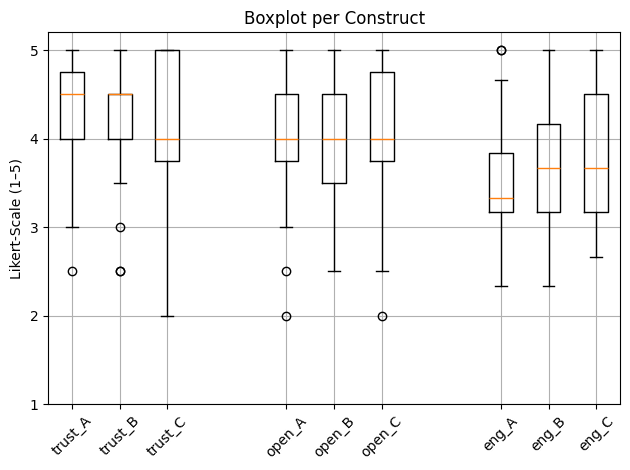

In [167]:
df = pd.read_csv('daten.csv') 

# choose relevant cols
cols = ['trust_A','trust_B','trust_C',
        'open_A','open_B','open_C',
        'eng_A','eng_B','eng_C']


groups = {
    "Trust": ['trust_A','trust_B','trust_C'],
    "Open": ['open_A','open_B','open_C'],
    "Eng": ['eng_A','eng_B','eng_C']
}

data = []
positions = []
labels = []

pos = 1
gap = 1.5

for group_name, cols in groups.items():
    for col in cols:
        data.append(df[col].dropna())
        positions.append(pos)
        labels.append(col)
        pos += 1
    pos += gap  # additional gap between constructs

# Plot
plt.figure()

plt.boxplot(data, positions=positions)

# set x-axis labels
plt.xticks(positions, labels, rotation=45)

# set y-axis
plt.ylim(1, 5.2)
plt.yticks([1,2,3,4,5])

plt.ylabel('Likert-Scale (1–5)')
plt.title('Boxplot per Construct')

plt.grid()

plt.tight_layout()
plt.show()


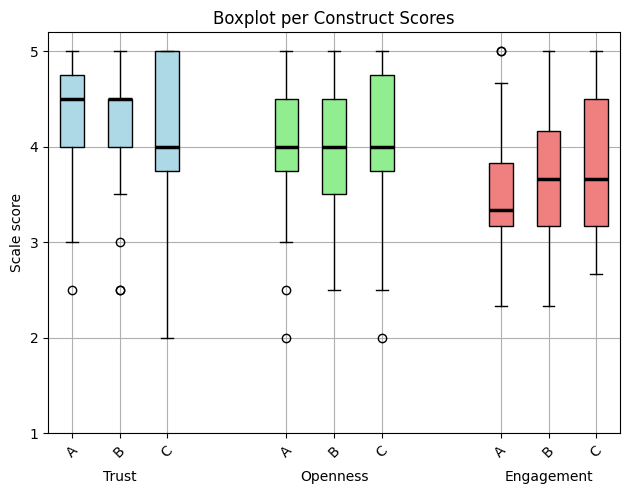

In [168]:
groups = {
    "Trust": ['trust_A','trust_B','trust_C'],
    "Openness": ['open_A','open_B','open_C'],
    "Engagement": ['eng_A','eng_B','eng_C']
}

data = []
positions = []
labels = []
colors = []

pos = 1
gap = 1.5

# each construct own color
group_colors = {
    "Trust": "lightblue",
    "Openness": "lightgreen",
    "Engagement": "lightcoral"
}

for group_name, cols in groups.items():
    for col in cols:
        data.append(df[col].dropna())
        positions.append(pos)
        labels.append(col.split('_')[1])  # ergibt A, B oder C
        colors.append(group_colors[group_name])
        pos += 1
    pos += gap

# plot
plt.figure()

box = plt.boxplot(
    data,
    positions=positions,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2.5)
)

# colors
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# axis
plt.xticks(positions, labels, rotation=45)
plt.ylim(1, 5.2)
plt.yticks([1,2,3,4,5])

plt.ylabel('Scale score')
plt.title('Boxplot per Construct Scores')

plt.grid()
plt.tight_layout()
# median per group
group_centers = [
    sum(positions[0:3]) / 3,
    sum(positions[3:6]) / 3,
    sum(positions[6:9]) / 3
]

# construct labels below group centers
for center, name in zip(group_centers, groups.keys()):
    plt.text(center, 0.5, name, ha='center')

plt.xticks(positions, labels)
plt.show()

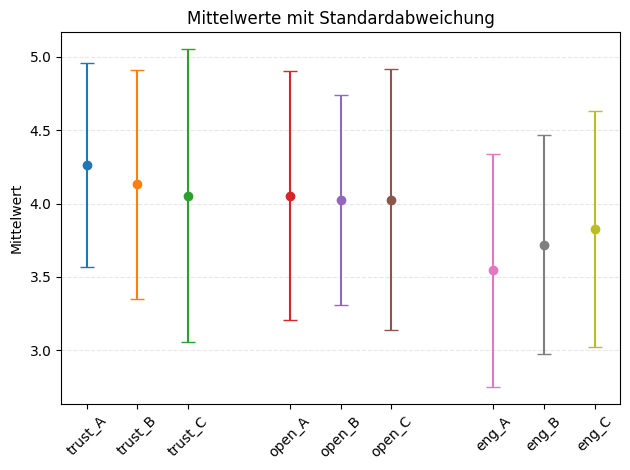

In [169]:
# only relevant cols
cols = ['trust_A','trust_B','trust_C',
        'open_A','open_B','open_C',
        'eng_A','eng_B','eng_C']

# show means and standard deviations
means = df[cols].mean()
stds = df[cols].std()

# define scales
groups = {
    "Trust": ['trust_A','trust_B','trust_C'],
    "Open": ['open_A','open_B','open_C'],
    "Eng": ['eng_A','eng_B','eng_C']
}

plt.figure()

x_positions = []
x_labels = []
current_x = 0

# show for each scale mean and std
for group_name, variables in groups.items():
    for var in variables:
        plt.errorbar(current_x,
                     means[var],
                     yerr=stds[var],
                     fmt='o',
                     capsize=5)
        x_positions.append(current_x)
        x_labels.append(var)
        current_x += 1
    
    current_x += 1  # Abstand zwischen Gruppen

plt.xticks(x_positions, x_labels, rotation=45)
plt.ylabel("Mittelwert")
plt.title("Mittelwerte mit Standardabweichung")
plt.tight_layout()
plt.grid(axis='y', linestyle="--", alpha=0.3)
plt.show()

trust_A    4.263158
trust_B    4.131579
trust_C    4.052632
open_A     4.052632
open_B     4.026316
open_C     4.026316
eng_A      3.543860
eng_B      3.719298
eng_C      3.824561
dtype: float64 trust_A    0.159350
trust_B    0.178698
trust_C    0.229080
open_A     0.194571
open_B     0.164342
open_C     0.204030
eng_A      0.182415
eng_B      0.171496
eng_C      0.184466
dtype: float64


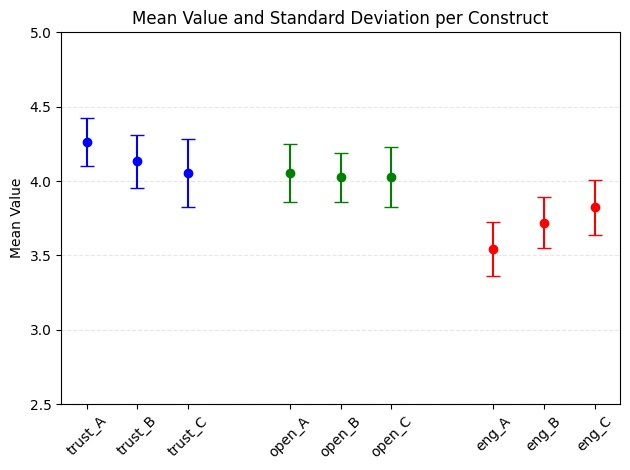

In [170]:

# only relevant cols
cols = ['trust_A','trust_B','trust_C',
        'open_A','open_B','open_C',
        'eng_A','eng_B','eng_C']

# use means and standard errors
means = df[cols].mean()
ses = df[cols].sem()

print(means, ses)


# bigger spaces between groups
x_positions = [
    0, 1, 2,        # trust
    4, 5, 6,        # open 
    8, 9, 10        # eng   
]

# one color per scale
colors = (
    ["blue"]*3 +   # trust
    ["green"]*3 +  # open
    ["red"]*3      # eng
)

plt.figure()

# show means and standard errors
for i, col in enumerate(cols):
    plt.errorbar(x_positions[i],
                 means[col],
                 yerr=ses[col],
                 fmt='o',
                 capsize=5,
                 color=colors[i])

plt.xticks(x_positions, cols, rotation=45)
plt.ylabel("Mean Value")
plt.title("Mean Value and Standard Deviation per Construct")

# fix y-axis to 2.5 to 5
plt.ylim(2.5, 5)

plt.tight_layout()
plt.grid(axis='y', linestyle="--", alpha=0.3)
plt.show()

In [171]:
# Repeated Measures ANOVA - Trust

#Long-Format erstellen (von 1 Zeile pro Person zu 3 Zeilen pro Person: eine Spalte variant & eine trust)
trust_long = pd.melt(df,
                     id_vars=['Zeitstempel'],
                     value_vars=['trust_A', 'trust_B', 'trust_C'],
                     var_name='variant',
                     value_name='trust')

#ANOVA berechnen
aov_trust = pg.rm_anova(dv='trust',
                        within='variant',
                        subject='Zeitstempel',
                        data=trust_long,
                        detailed=True)

print(aov_trust)

    Source        SS  DF        MS         F     p-unc       ng2       eps
0  variant  0.429825   2  0.214912  1.069091  0.353969  0.011316  0.895073
1    Error  7.236842  36  0.201023       NaN       NaN       NaN       NaN


In [172]:
# Repeated Measures ANOVA - Openness

open_long = pd.melt(df,
                    id_vars=['Zeitstempel'],
                    value_vars=['open_A', 'open_B', 'open_C'],
                    var_name='variant',
                    value_name='open')


aov_open = pg.rm_anova(dv='open',
                       within='variant',
                       subject='Zeitstempel',
                       data=open_long,
                       detailed=True)

print(aov_open)

    Source        SS  DF        MS         F     p-unc       ng2       eps
0  variant  0.008772   2  0.004386  0.027108  0.973276  0.000241  0.930357
1    Error  5.824561  36  0.161793       NaN       NaN       NaN       NaN


In [173]:
# Repeated Measures ANOVA - Engagement

eng_long = pd.melt(df,
                   id_vars=['Zeitstempel'],
                   value_vars=['eng_A', 'eng_B', 'eng_C'],
                   var_name='variant',
                   value_name='eng')


aov_eng = pg.rm_anova(dv='eng',
                      within='variant',
                      subject='Zeitstempel',
                      data=eng_long,
                      detailed=True)

print(aov_eng)

    Source        SS  DF        MS         F     p-unc       ng2       eps
0  variant  0.764133   2  0.382066  2.554671  0.091731  0.022581  0.975226
1    Error  5.384016  36  0.149556       NaN       NaN       NaN       NaN


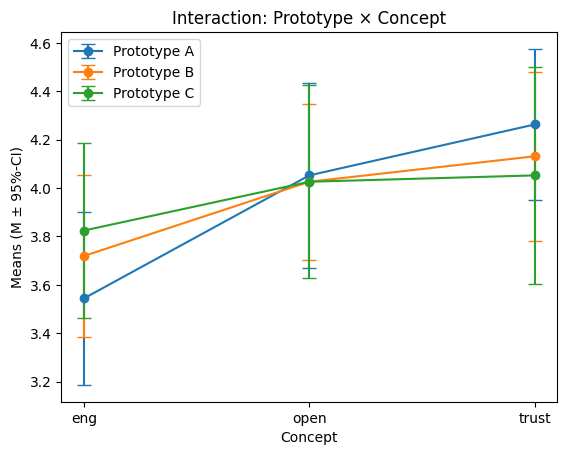

In [174]:
# Long Format (alle 9 Spalten)
cols = ["eng_A","eng_B","eng_C",
        "open_A","open_B","open_C",
        "trust_A","trust_B","trust_C"]

long = df.melt(id_vars=["Zeitstempel"], value_vars=cols,
               var_name="cond", value_name="score")

# split cond into concept + prototype
long[["concept","prototype"]] = long["cond"].str.split("_", expand=True)

# plotting (M ± 95%-CI)
summary = (long.groupby(["prototype","concept"])["score"]
           .agg(mean="mean", sd="std", n="count")
           .reset_index())
summary["se"] = summary["sd"] / np.sqrt(summary["n"])
summary["ci95"] = 1.96 * summary["se"]

fig, ax = plt.subplots()
for proto in sorted(summary["prototype"].unique()):
    sub = summary[summary["prototype"] == proto].sort_values("concept")
    ax.errorbar(sub["concept"], sub["mean"], yerr=sub["ci95"],
                marker="o", capsize=5, label=f"Prototype {proto}")

ax.set_xlabel("Concept")
ax.set_ylabel("Means (M ± 95%-CI)")
ax.set_title("Interaction: Prototype × Concept")
ax.legend()
plt.show()

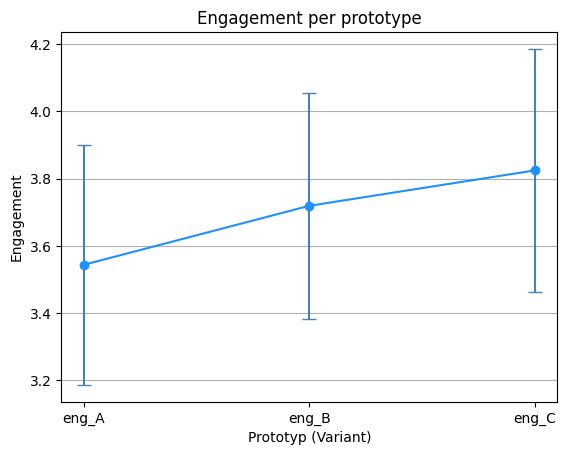

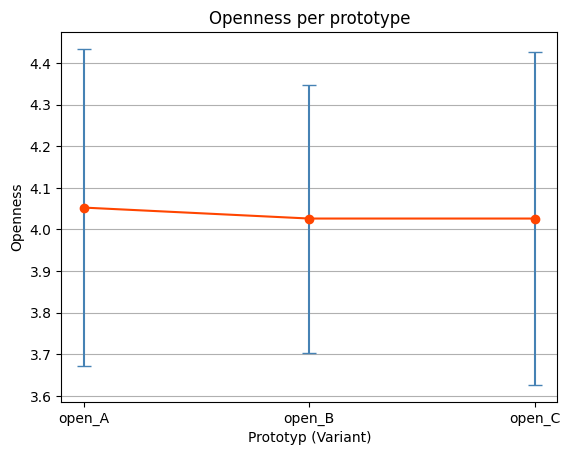

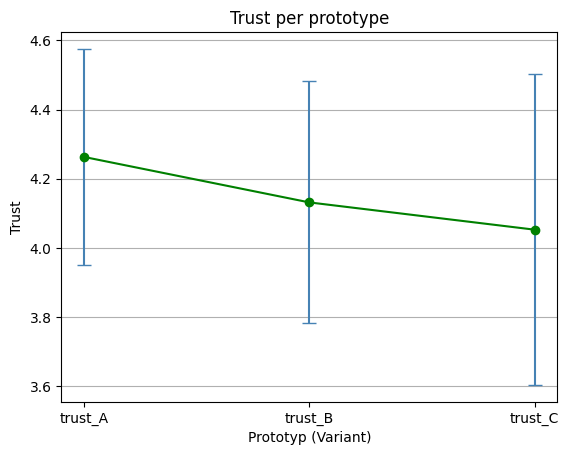

In [175]:
# Same but for each construct one plot:

def mean_ci95_by_variant(long_df, dv, within="variant"):
    s = (long_df
         .groupby(within)[dv]
         .agg(mean="mean", sd="std", n="count")
         .reset_index())
    s["se"] = s["sd"] / np.sqrt(s["n"])
    s["ci95"] = 1.96 * s["se"]
    return s

def plot_one_concept(long_df, dv, title, color, ylabel):
    s = mean_ci95_by_variant(long_df, dv)
    x = s["variant"].astype(str).values
    y = s["mean"].values
    yerr = s["ci95"].values

    fig, ax = plt.subplots()
    ax.errorbar(x, y, yerr=yerr, marker="o", capsize=5, color=color, ecolor='steelblue')
    ax.set_xlabel("Prototyp (Variant)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.grid(axis='y')
    plt.show()

# Deine Long-DFs plotten:
plot_one_concept(eng_long, dv="eng",   title="Engagement per prototype", color="dodgerblue", ylabel="Engagement")
plot_one_concept(open_long, dv="open", title="Openness per prototype", color="orangered", ylabel="Openness")
plot_one_concept(trust_long, dv="trust", title="Trust per prototype", color="green", ylabel="Trust")

In [176]:
eng_long["variant"] = eng_long["variant"].str.replace("eng_", "", regex=False)
open_long["variant"] = open_long["variant"].str.replace("open_", "", regex=False)
trust_long["variant"] = trust_long["variant"].str.replace("trust_", "", regex=False)

In [177]:
# Q: Which prototype is most engaging? (Engagement)

df['most_engaging'].value_counts()


most_engaging
Prototype B                9
Prototype C                4
Prototype A;Prototype C    2
Prototype B;Prototype C    2
Prototype A                2
Name: count, dtype: int64

In [178]:
# Q: Which prototype is most open? (Openness)

df['most_open'].value_counts()

#df_trust_split.sum() / len(df) * 100


most_open
Prototype B                            9
Prototype C                            4
Prototype A                            3
Prototype A;Prototype B;Prototype C    2
Prototype B;Prototype C                1
Name: count, dtype: int64

In [179]:
# Q: Which prototype is most trusted? (Trust)
df['most_trust'].value_counts()


most_trust
Prototype C                            6
Prototype B                            5
Prototype A;Prototype B;Prototype C    4
Prototype A                            3
Prototype A;Prototype C                1
Name: count, dtype: int64

In [180]:
# Cochran's Q (Engagement)

# make binary Cols
eng_split = df['most_engaging'].str.get_dummies(sep=';')
eng_split = eng_split[['Prototype A', 'Prototype B', 'Prototype C']]  # Reihenfolge fix
eng_split.head()

# calculate Cochran's Q 
pg.cochran(eng_split)

,Source,dof,Q,p-unc
cochran,Within,2,3.894737,0.142649


In [181]:
# Cochran's Q (Openness)
open_split = df['most_open'].str.get_dummies(sep=';')
open_split = open_split[['Prototype A', 'Prototype B', 'Prototype C']]
pg.cochran(open_split)

,Source,dof,Q,p-unc
cochran,Within,2,4.588235,0.10085


In [182]:
# Cochran's Q (Trust)
trust_split = df['most_trust'].str.get_dummies(sep=';')
trust_split = trust_split[['Prototype A', 'Prototype B', 'Prototype C']]
pg.cochran(trust_split)

,Source,dof,Q,p-unc
cochran,Within,2,0.933333,0.627089


In [183]:
df = pd.read_csv("chatbot_debate_user_study_V2.csv") 

In [184]:
# eindeutige Teilnehmer-ID
df = df.copy()
df["participant_id"] = df.index.astype(str)

prototypes = ["A", "B", "C"]
rows = []

for _, row in df.iterrows():
    for p in prototypes:
        rows.append({
            "participant_id": row["participant_id"],
            "prototype": p,
            "role": row[f"role_{p}"],
            "engagement": pd.to_numeric(
                row[[f"eng1_{p}", f"eng2_{p}", f"eng3_{p}"]],
                errors="coerce"
            ).mean(),
            "trust": pd.to_numeric(
                row[[f"trust1_{p}", f"trust2_{p}"]],
                errors="coerce"
            ).mean(),
            "openness": pd.to_numeric(
                row[[f"open1_{p}", f"open2_{p}"]],
                errors="coerce"
            ).mean(),
        })

long = pd.DataFrame(rows)

# als Kategorien setzen
long["prototype"] = pd.Categorical(long["prototype"])
long["role"] = pd.Categorical(long["role"])

print("Long-Format erstellt.")
print(long.head())

Long-Format erstellt.
  participant_id prototype                                               role  \
0              0         A  Aktiv an der Debatte teilnehmen / Be an active...   
1              0         B  Aktiv an der Debatte teilnehmen / Be an active...   
2              0         C  Aktiv an der Debatte teilnehmen / Be an active...   
3              1         A  Fragen stellen und kommentieren / Ask question...   
4              1         B  Aktiv an der Debatte teilnehmen / Be an active...   

   engagement  trust  openness  
0    2.666667    4.0       4.0  
1    2.666667    3.5       4.0  
2    3.333333    4.0       4.0  
3    2.333333    4.0       4.5  
4    4.000000    4.5       3.5  


In [185]:
long["role"].value_counts()

role
Fragen stellen und kommentieren / Ask questions and comment          36
Aktiv an der Debatte teilnehmen / Be an active part of the debate    19
Beide / Both                                                          2
Name: count, dtype: int64

In [186]:
d = long.dropna(subset=["engagement", "role", "prototype"]).copy()

role_s = d["role"].astype(str).str.strip()

# put both into active category
d["role2"] = role_s.replace({
    "Beide / Both": "Aktiv an der Debatte teilnehmen / Be an active part of the debate"
})

# shorter labels
d["role2"] = d["role2"].replace({
    "Aktiv an der Debatte teilnehmen / Be an active part of the debate": "active",
    "Fragen stellen und kommentieren / Ask questions and comment": "passive"
})

d["role2"] = d["role2"].astype("category")

print(d["role2"].value_counts())

role2
passive    36
active     21
Name: count, dtype: int64


In [187]:
#active_flag erstellen (=> 0=comment, 1=active/both)
d = long.dropna(subset=["engagement", "role", "prototype"]).copy()

role_s = d["role"].astype(str)

d["active_flag"] = role_s.str.contains("Aktiv|Be an active", regex=True).astype(int)
d.loc[role_s.str.contains("Both|Beide", regex=True), "active_flag"] = 1

print(pd.crosstab(d["prototype"], d["active_flag"]))

active_flag   0  1
prototype         
A            14  5
B            11  8
C            11  8


In [188]:
from statsmodels.formula.api import mixedlm

m = mixedlm(
    "engagement ~ C(prototype) * active_flag",
    d,
    groups=d["participant_id"]
)

res = m.fit(reml=False, method="lbfgs")
print(res.summary())

                 Mixed Linear Model Regression Results
Model:                  MixedLM      Dependent Variable:      engagement
No. Observations:       57           Method:                  ML        
No. Groups:             19           Scale:                   0.1384    
Min. group size:        3            Log-Likelihood:          -46.8637  
Max. group size:        3            Converged:               Yes       
Mean group size:        3.0                                             
------------------------------------------------------------------------
                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------
Intercept                      3.574    0.185 19.338 0.000  3.212  3.936
C(prototype)[T.B]              0.161    0.158  1.019 0.308 -0.149  0.471
C(prototype)[T.C]              0.178    0.161  1.100 0.271 -0.139  0.494
active_flag                   -0.115    0.234 -0.491 0.623 -0.574  0.

In [189]:
path = "chatbot_debate_user_study_V2.csv"
df = pd.read_csv(path)

df["participant_id"] = np.arange(len(df)) + 1

# put both into active category
role_map = {
    "Aktiv an der Debatte teilnehmen / Be an active part of the debate": "active",
    "Fragen stellen und kommentieren / Ask questions and comment": "ask",
    "Beide / Both": "active"
}

# Long Format
prototypes = ["A","B","C"]

long_parts = []

for p in prototypes:

    temp = pd.DataFrame({
        "participant_id": df["participant_id"],
        "prototype": p,
        "role": df[f"role_{p}"].map(role_map),
        "eng1": df[f"eng1_{p}"],
        "eng2": df[f"eng2_{p}"],
        "eng3": df[f"eng3_{p}"],
        "trust1": df[f"trust1_{p}"],
        "trust2": df[f"trust2_{p}"],
        "open1": df[f"open1_{p}"],
        "open2": df[f"open2_{p}"]
    })

    long_parts.append(temp)

long_df = pd.concat(long_parts, ignore_index=True)


# calculate means for scales

long_df["eng"] = long_df[["eng1","eng2","eng3"]].mean(axis=1)
long_df["trust"] = long_df[["trust1","trust2"]].mean(axis=1)
long_df["open"] = long_df[["open1","open2"]].mean(axis=1)


# Mixed Models comparing Prototype A to B and C
outcomes = ["eng","trust","open"]

rows = []

for outcome in outcomes:

    d = long_df[["participant_id","role","prototype",outcome]].dropna()

    model = smf.mixedlm(
        f"{outcome} ~ C(role) + C(prototype)",
        d,
        groups=d["participant_id"]
    )

    fit = model.fit(reml=True)

    for term in fit.fe_params.index:

        rows.append({
            "outcome": outcome,
            "term": term,
            "coef": fit.fe_params[term],
            "std_err": fit.bse_fe[term],
            "z": fit.tvalues[term],
            "p_value": fit.pvalues[term],
            "ci_lower": fit.conf_int().loc[term,0],
            "ci_upper": fit.conf_int().loc[term,1],
            "logLik": fit.llf,
            "group_var": fit.cov_re.iloc[0,0],
            "n_obs": d.shape[0],
            "n_groups": d["participant_id"].nunique()
        })

# make table
results_table = pd.DataFrame(rows)

# round for better readability
results_table = results_table.round(3)

# save data in file
results_table.to_csv("mixedlm_scale_results.csv", index=False)

print("Ergebnisse gespeichert als: mixedlm_scale_results.csv")
print(results_table)

Ergebnisse gespeichert als: mixedlm_scale_results.csv
   outcome               term   coef  std_err       z  p_value  ci_lower  \
0      eng          Intercept  3.560    0.205  17.330    0.000     3.157   
1      eng     C(role)[T.ask] -0.021    0.133  -0.160    0.873    -0.282   
2      eng  C(prototype)[T.B]  0.172    0.129   1.338    0.181    -0.080   
3      eng  C(prototype)[T.C]  0.277    0.129   2.156    0.031     0.025   
4    trust          Intercept  4.189    0.221  18.932    0.000     3.755   
5    trust     C(role)[T.ask]  0.101    0.153   0.661    0.508    -0.198   
6    trust  C(prototype)[T.B] -0.116    0.149  -0.775    0.438    -0.408   
7    trust  C(prototype)[T.C] -0.195    0.149  -1.304    0.192    -0.487   
8     open          Intercept  3.938    0.211  18.628    0.000     3.524   
9     open     C(role)[T.ask]  0.156    0.137   1.134    0.257    -0.113   
10    open  C(prototype)[T.B] -0.002    0.133  -0.013    0.989    -0.262   
11    open  C(prototype)[T.C] -0.0

In [190]:
# Mixed Models comparing Prototypes B to A and C
outcomes = ["eng","trust","open"]

rows = []

for outcome in outcomes:

    d = long_df[["participant_id","role","prototype",outcome]].dropna()

    model = smf.mixedlm(
        f"{outcome} ~ C(role) + C(prototype, Treatment(reference='B'))",
        d,
        groups=d["participant_id"]
    )

    fit = model.fit(reml=True)

    for term in fit.fe_params.index:

        rows.append({
            "outcome": outcome,
            "term": term,
            "coef": fit.fe_params[term],
            "std_err": fit.bse_fe[term],
            "z": fit.tvalues[term],
            "p_value": fit.pvalues[term],
            "ci_lower": fit.conf_int().loc[term,0],
            "ci_upper": fit.conf_int().loc[term,1],
            "logLik": fit.llf,
            "group_var": fit.cov_re.iloc[0,0],
            "n_obs": d.shape[0],
            "n_groups": d["participant_id"].nunique()
        })

# make table
results_table = pd.DataFrame(rows)

# round for better readability
results_table = results_table.round(3)

# save data
results_table.to_csv("mixedlm_pB_results.csv", index=False)

print("Ergebnisse gespeichert als: mixedlm_scale_results.csv")
print(results_table)


Ergebnisse gespeichert als: mixedlm_scale_results.csv
   outcome                                         term   coef  std_err  \
0      eng                                    Intercept  3.732    0.196   
1      eng                               C(role)[T.ask] -0.021    0.133   
2      eng  C(prototype, Treatment(reference='B'))[T.A] -0.172    0.129   
3      eng  C(prototype, Treatment(reference='B'))[T.C]  0.105    0.127   
4    trust                                    Intercept  4.073    0.210   
5    trust                               C(role)[T.ask]  0.101    0.153   
6    trust  C(prototype, Treatment(reference='B'))[T.A]  0.116    0.149   
7    trust  C(prototype, Treatment(reference='B'))[T.C] -0.079    0.147   
8     open                                    Intercept  3.936    0.202   
9     open                               C(role)[T.ask]  0.156    0.137   
10    open  C(prototype, Treatment(reference='B'))[T.A]  0.002    0.133   
11    open  C(prototype, Treatment(reference='

In [191]:
# Mixed Models comparing Prototype C to A and B
outcomes = ["eng","trust","open"]

rows = []

for outcome in outcomes:

    d = long_df[["participant_id","role","prototype",outcome]].dropna()

    model = smf.mixedlm(
        f"{outcome} ~ C(role) + C(prototype, Treatment(reference='C'))",
        d,
        groups=d["participant_id"]
    )

    fit = model.fit(reml=True)

    for term in fit.fe_params.index:

        rows.append({
            "outcome": outcome,
            "term": term,
            "coef": fit.fe_params[term],
            "std_err": fit.bse_fe[term],
            "z": fit.tvalues[term],
            "p_value": fit.pvalues[term],
            "ci_lower": fit.conf_int().loc[term,0],
            "ci_upper": fit.conf_int().loc[term,1],
            "logLik": fit.llf,
            "group_var": fit.cov_re.iloc[0,0],
            "n_obs": d.shape[0],
            "n_groups": d["participant_id"].nunique()
        })

# make table
results_table = pd.DataFrame(rows)

# round for better readability
results_table = results_table.round(3)

# save data
results_table.to_csv("mixedlm_pC_results.csv", index=False)

print("Ergebnisse gespeichert als: mixedlm_scale_results.csv")
print(results_table)


Ergebnisse gespeichert als: mixedlm_scale_results.csv
   outcome                                         term   coef  std_err  \
0      eng                                    Intercept  3.837    0.196   
1      eng                               C(role)[T.ask] -0.021    0.133   
2      eng  C(prototype, Treatment(reference='C'))[T.A] -0.277    0.129   
3      eng  C(prototype, Treatment(reference='C'))[T.B] -0.105    0.127   
4    trust                                    Intercept  3.994    0.210   
5    trust                               C(role)[T.ask]  0.101    0.153   
6    trust  C(prototype, Treatment(reference='C'))[T.A]  0.195    0.149   
7    trust  C(prototype, Treatment(reference='C'))[T.B]  0.079    0.147   
8     open                                    Intercept  3.936    0.202   
9     open                               C(role)[T.ask]  0.156    0.137   
10    open  C(prototype, Treatment(reference='C'))[T.A]  0.002    0.133   
11    open  C(prototype, Treatment(reference='